#### Task 1: Dataset Preparation

In [1]:
# Import dependencies
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# Transform for visualization (raw 32x32 images, pixel values in [0,1])
display_transform = transforms.ToTensor()

# Transform for the model (resized to 224x224 for VGG16, pixel values in [0,1])
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [4]:
# Load Train dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    download=True,
    train=True,
    transform=train_transform
)

# Dataset used only for displaying raw sample images
display_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    download=True,
    train=True,
    transform=display_transform
)

100%|██████████| 170M/170M [26:05<00:00, 109kB/s]


In [5]:
# Load Test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    download=True,
    train=False,
    transform=test_transform
)

In [6]:
# Validation Split
train_size = 45000
validation_size = 5000

train_subset, validation_subset = random_split(
    train_dataset,
    [train_size, validation_size]
)

In [7]:
# Print Dataset Dimensions
print("Training Dataset :", len(train_dataset))
print("Testing Dataset  :", len(test_dataset))

image, label = display_dataset[0]
print("Image Shape :", image.shape)
print("Label       :", label)

Training Dataset : 50000
Testing Dataset  : 10000
Image Shape : torch.Size([3, 32, 32])
Label       : 6


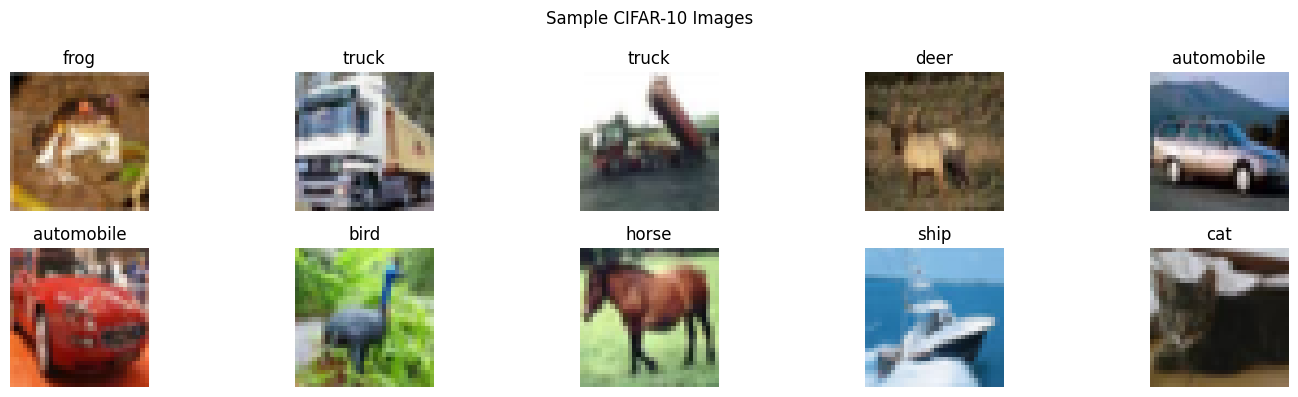

In [8]:
# Display first 10 sample images
classes = display_dataset.classes

plt.figure(figsize=(15, 4))

for i in range(10):
    image, label = display_dataset[i]
    plt.subplot(2, 5, i + 1)
    image = image.permute(1, 2, 0)
    plt.imshow(image)
    plt.title(classes[label])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

**Inference:** The CIFAR-10 dataset consists of 60,000 32x32 colour images spread across 10 balanced classes, with 50,000 used for training and 10,000 for testing.

#### Task 2: Transfer Learning - Model Setup (VGG16)

In [9]:
# Load VGG16 pretrained on ImageNet
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
print(vgg16)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 88.9MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [10]:
# Remove the original classifier and freeze the convolutional base
class TransferCNN(nn.Module):

    def __init__(self, base_model, num_classes=10):
        super().__init__()

        # Convolutional base (feature extractor) of the pretrained model
        self.features = base_model.features

        # Freeze all convolutional layers
        for param in self.features.parameters():
            param.requires_grad = False

        # Global Average Pooling layer
        self.gap = nn.AdaptiveAvgPool2d(1)

        # New classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)   # Softmax applied via CrossEntropyLoss
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

In [11]:
# Create the model
model = TransferCNN(vgg16, num_classes=10).to(device)
print(model)

TransferCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, di

In [12]:
# Count trainable vs total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Parameters     :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters     : 14848586
Trainable Parameters : 133898


#### Task 3: Model Training

In [13]:
# Create Data Loaders
batch_size = 32

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
validation_loader = DataLoader(validation_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [14]:
# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

In [15]:
# Training loop
def train_model(model, optimizer, epochs):

    train_loss_history = []
    train_accuracy_history = []
    validation_loss_history = []
    validation_accuracy_history = []

    for epoch in range(epochs):

        # =========================
        # TRAINING
        # =========================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        # =========================
        # VALIDATION
        # =========================
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in validation_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        validation_loss = val_running_loss / val_total
        validation_accuracy = 100 * val_correct / val_total

        train_loss_history.append(train_loss)
        train_accuracy_history.append(train_accuracy)
        validation_loss_history.append(validation_loss)
        validation_accuracy_history.append(validation_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Train Acc: {train_accuracy:.2f}% "
              f"Val Loss: {validation_loss:.4f} Val Acc: {validation_accuracy:.2f}%")

    return train_loss_history, train_accuracy_history, validation_loss_history, validation_accuracy_history

In [19]:
# Train the model (frozen convolutional base)
epochs = 10

(train_loss_history, train_accuracy_history,
 validation_loss_history, validation_accuracy_history) = train_model(model, optimizer, epochs)

Epoch [1/10] Train Loss: 0.1475 Train Acc: 95.06% Val Loss: 0.4225 Val Acc: 89.04%
Epoch [2/10] Train Loss: 0.1306 Train Acc: 95.81% Val Loss: 0.4778 Val Acc: 89.00%
Epoch [3/10] Train Loss: 0.1269 Train Acc: 95.90% Val Loss: 0.4942 Val Acc: 88.56%
Epoch [4/10] Train Loss: 0.1272 Train Acc: 95.90% Val Loss: 0.5203 Val Acc: 88.44%
Epoch [5/10] Train Loss: 0.1219 Train Acc: 96.06% Val Loss: 0.5178 Val Acc: 89.10%
Epoch [6/10] Train Loss: 0.1222 Train Acc: 96.05% Val Loss: 0.5082 Val Acc: 88.96%
Epoch [7/10] Train Loss: 0.1194 Train Acc: 96.26% Val Loss: 0.5163 Val Acc: 88.98%
Epoch [8/10] Train Loss: 0.1194 Train Acc: 96.28% Val Loss: 0.5216 Val Acc: 89.00%
Epoch [9/10] Train Loss: 0.1151 Train Acc: 96.30% Val Loss: 0.5313 Val Acc: 89.06%
Epoch [10/10] Train Loss: 0.1179 Train Acc: 96.31% Val Loss: 0.5391 Val Acc: 89.52%


In [20]:
# Accuracy before fine tuning
accuracy_before_finetune = validation_accuracy_history[-1]
print(f"Validation Accuracy Before Fine Tuning: {accuracy_before_finetune:.2f}%")

Validation Accuracy Before Fine Tuning: 89.52%


#### Task 4: Fine Tuning

In [21]:
# Unfreeze the last convolutional block of VGG16
# VGG16 features: last block is layers 24 to 30 (5th conv block + pooling)
for name, param in model.features.named_parameters():
    layer_index = int(name.split('.')[0])
    if layer_index >= 24:
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable Parameters After Unfreezing:", trainable_params)

Trainable Parameters After Unfreezing: 7213322


In [22]:
# Re-create optimizer with a lower learning rate for fine tuning
finetune_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

finetune_epochs = 5

(ft_train_loss_history, ft_train_accuracy_history,
 ft_validation_loss_history, ft_validation_accuracy_history) = train_model(
    model, finetune_optimizer, finetune_epochs
)

Epoch [1/5] Train Loss: 0.1829 Train Acc: 94.37% Val Loss: 0.4934 Val Acc: 86.70%
Epoch [2/5] Train Loss: 0.1203 Train Acc: 96.06% Val Loss: 0.5108 Val Acc: 88.68%
Epoch [3/5] Train Loss: 0.0966 Train Acc: 96.82% Val Loss: 0.5018 Val Acc: 88.32%
Epoch [4/5] Train Loss: 0.0760 Train Acc: 97.44% Val Loss: 0.5194 Val Acc: 88.62%
Epoch [5/5] Train Loss: 0.0582 Train Acc: 98.17% Val Loss: 0.5375 Val Acc: 88.44%


In [23]:
# Combine training history from both phases
train_loss_history += ft_train_loss_history
train_accuracy_history += ft_train_accuracy_history
validation_loss_history += ft_validation_loss_history
validation_accuracy_history += ft_validation_accuracy_history

accuracy_after_finetune = validation_accuracy_history[-1]

print(f"Validation Accuracy Before Fine Tuning : {accuracy_before_finetune:.2f}%")
print(f"Validation Accuracy After Fine Tuning  : {accuracy_after_finetune:.2f}%")

Validation Accuracy Before Fine Tuning : 89.52%
Validation Accuracy After Fine Tuning  : 88.44%


#### Task 5: Model Evaluation

In [24]:
# Import evaluation metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [25]:
# Testing loop
model.eval()

all_predictions = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [26]:
# Accuracy
test_accuracy = 100 * correct / total

# Precision
precision = precision_score(all_labels, all_predictions, average="weighted")

# Recall
recall = recall_score(all_labels, all_predictions, average="weighted")

# F1 Score
f1 = f1_score(all_labels, all_predictions, average="weighted")

print(f"Testing Accuracy : {test_accuracy:.2f}%")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1 Score         : {f1:.4f}")

Testing Accuracy : 88.03%
Precision        : 0.8809
Recall           : 0.8803
F1 Score         : 0.8799


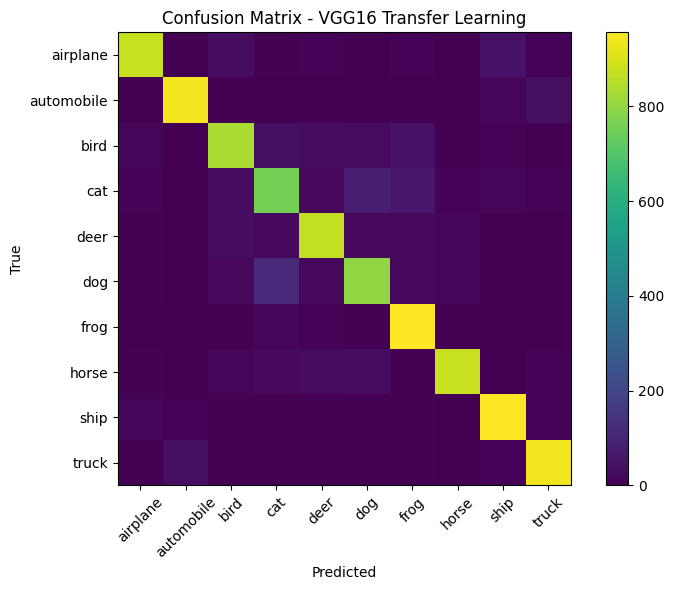

In [27]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix - VGG16 Transfer Learning")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)
plt.tight_layout()
plt.show()

In [28]:
# Classification Report
print(classification_report(all_labels, all_predictions, target_names=classes))

              precision    recall  f1-score   support

    airplane       0.93      0.88      0.90      1000
  automobile       0.94      0.94      0.94      1000
        bird       0.85      0.83      0.84      1000
         cat       0.77      0.76      0.77      1000
        deer       0.88      0.87      0.87      1000
         dog       0.82      0.80      0.81      1000
        frog       0.84      0.96      0.89      1000
       horse       0.94      0.88      0.91      1000
        ship       0.90      0.95      0.93      1000
       truck       0.92      0.94      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



**Inference:** The confusion matrix and classification report highlight which classes are frequently confused (e.g. visually similar classes such as cat/dog or automobile/truck), helping identify where the model needs improvement.

#### Mandatory Plots

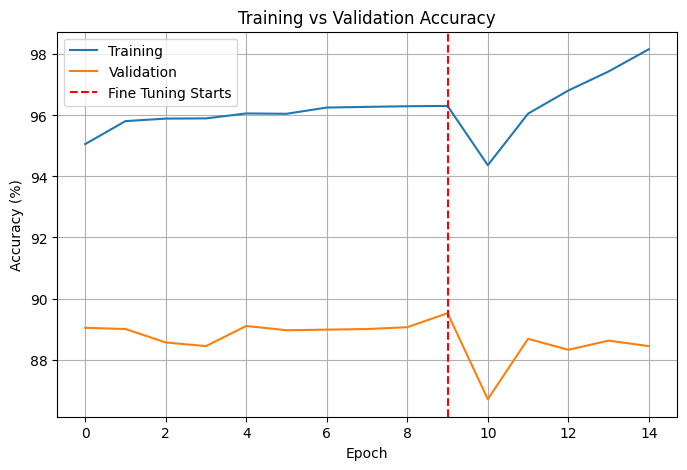

In [29]:
# Training Accuracy vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_history, label="Training")
plt.plot(validation_accuracy_history, label="Validation")
plt.axvline(x=epochs - 1, color='red', linestyle='--', label='Fine Tuning Starts')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

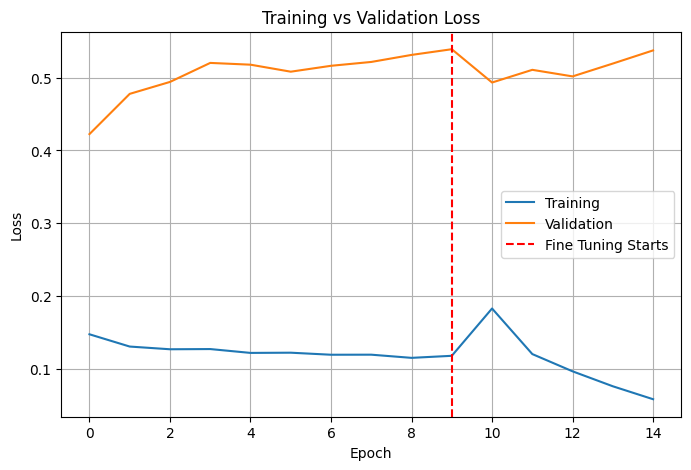

In [30]:
# Training Loss vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Training")
plt.plot(validation_loss_history, label="Validation")
plt.axvline(x=epochs - 1, color='red', linestyle='--', label='Fine Tuning Starts')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

**Inference:** Both training and validation curves should show accuracy increasing and loss decreasing over epochs, with a further shift visible after fine tuning begins.

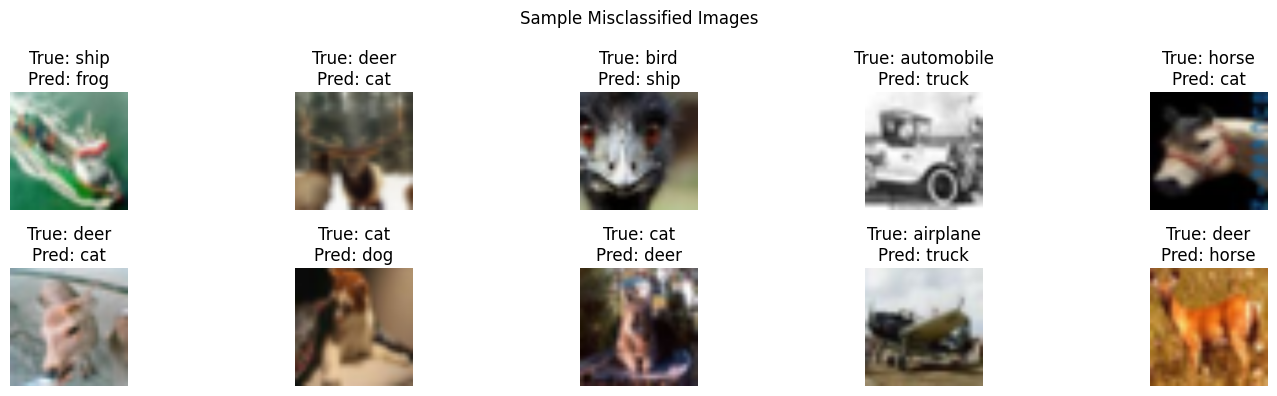

In [31]:
# Misclassified Images (Optional)
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

misclassified_indices = np.where(all_predictions != all_labels)[0][:10]

plt.figure(figsize=(15, 4))

for i, idx in enumerate(misclassified_indices):
    image, true_label = test_dataset[idx]
    image = image.permute(1, 2, 0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(f"True: {classes[true_label]}\nPred: {classes[all_predictions[idx]]}")
    plt.axis("off")

plt.suptitle("Sample Misclassified Images")
plt.tight_layout()
plt.show()

**Inference:** Misclassified images often share visual similarities with the predicted class, such as similar colours, shapes, or backgrounds, which explains the model's confusion.